# Heart Disease Prediction System
## CardioSense — Cardiovascular Risk Assessment
**Name:** Neeraja R  
**Reg No:** U18IW23S0127  
**Guide:** Ms. Kusuma N, Assistant Professor  
**Department:** Computer Applications - BCA  
**College:** St. Francis College, Bengaluru – 560034  
**Academic Year:** 2025-26

---

### Project Overview
This notebook implements a **Heart Disease Prediction System** that classifies patients into three cardiovascular risk levels:
- 🟢 **Class 0 — Low Risk** (No Heart Disease)
- 🟡 **Class 1 — Medium Risk** (Borderline Condition)
- 🔴 **Class 2 — High Risk** (Heart Disease Detected)

Three Machine Learning models are trained and evaluated:
1. Logistic Regression
2. Random Forest Classifier
3. Support Vector Machine (SVM)


## Step 1: Import Libraries

In [1]:
# ── Standard Libraries ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')
import sklearn
print(f'Scikit-learn version: {sklearn.__version__}')

✅ All libraries imported successfully!
NumPy version      : 2.3.5
Pandas version     : 2.3.3
Scikit-learn version: 1.7.2


## Step 2: Dataset Generation

We generate a balanced synthetic dataset of **1,800 patient records** (600 per risk class) with clinical values matching the Cleveland Heart Disease Dataset distributions.

**13 Clinical Features Used:**
| Feature | Description |
|---------|-------------|
| age | Patient age in years |
| sex | Biological sex (1=Male, 0=Female) |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dL) |
| fbs | Fasting blood sugar > 120 mg/dL (1=Yes, 0=No) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved (bpm) |
| exang | Exercise induced angina (1=Yes, 0=No) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment (0–2) |
| ca | Number of major vessels coloured (0–3) |
| thal | Thalassemia type (1=Normal, 2=Fixed, 3=Reversible) |

In [2]:
np.random.seed(42)
N = 600  # samples per class

FEATURES = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal']

def make_patients(n, risk_level='low'):
    r = np.random.RandomState({'high':42,'medium':77,'low':99}[risk_level])
    if risk_level == 'high':
        age      = r.randint(55, 77, n)
        sex      = r.choice([0,1], n, p=[0.15, 0.85])
        cp       = r.choice([0,1,2,3], n, p=[0.02, 0.05, 0.10, 0.83])
        trestbps = r.randint(145, 200, n)
        chol     = r.randint(245, 400, n)
        fbs      = r.choice([0,1], n, p=[0.25, 0.75])
        restecg  = r.choice([0,1,2], n, p=[0.10, 0.60, 0.30])
        thalach  = r.randint(88, 130, n)
        exang    = r.choice([0,1], n, p=[0.10, 0.90])
        oldpeak  = np.round(r.uniform(2.0, 6.2, n), 1)
        slope    = r.choice([0,1,2], n, p=[0.05, 0.65, 0.30])
        ca       = r.choice([0,1,2,3], n, p=[0.05, 0.20, 0.35, 0.40])
        thal     = r.choice([1,2,3], n, p=[0.03, 0.15, 0.82])
        target   = np.full(n, 2, dtype=int)
    elif risk_level == 'medium':
        age      = r.randint(45, 62, n)
        sex      = r.choice([0,1], n, p=[0.40, 0.60])
        cp       = r.choice([0,1,2,3], n, p=[0.10, 0.30, 0.40, 0.20])
        trestbps = r.randint(128, 150, n)
        chol     = r.randint(210, 260, n)
        fbs      = r.choice([0,1], n, p=[0.60, 0.40])
        restecg  = r.choice([0,1,2], n, p=[0.35, 0.50, 0.15])
        thalach  = r.randint(120, 155, n)
        exang    = r.choice([0,1], n, p=[0.50, 0.50])
        oldpeak  = np.round(r.uniform(0.8, 2.2, n), 1)
        slope    = r.choice([0,1,2], n, p=[0.25, 0.55, 0.20])
        ca       = r.choice([0,1,2,3], n, p=[0.30, 0.45, 0.18, 0.07])
        thal     = r.choice([1,2,3], n, p=[0.20, 0.50, 0.30])
        target   = np.full(n, 1, dtype=int)
    else:
        age      = r.randint(25, 50, n)
        sex      = r.choice([0,1], n, p=[0.60, 0.40])
        cp       = r.choice([0,1,2,3], n, p=[0.60, 0.25, 0.12, 0.03])
        trestbps = r.randint(88, 128, n)
        chol     = r.randint(130, 210, n)
        fbs      = r.choice([0,1], n, p=[0.90, 0.10])
        restecg  = r.choice([0,1,2], n, p=[0.75, 0.18, 0.07])
        thalach  = r.randint(155, 202, n)
        exang    = r.choice([0,1], n, p=[0.90, 0.10])
        oldpeak  = np.round(r.uniform(0.0, 0.9, n), 1)
        slope    = r.choice([0,1,2], n, p=[0.65, 0.28, 0.07])
        ca       = r.choice([0,1,2,3], n, p=[0.78, 0.15, 0.05, 0.02])
        thal     = r.choice([1,2,3], n, p=[0.70, 0.22, 0.08])
        target   = np.full(n, 0, dtype=int)

    X = np.column_stack([age,sex,cp,trestbps,chol,fbs,restecg,
                         thalach,exang,oldpeak,slope,ca,thal])
    return X, target

# Generate all three risk classes
Xh, yh = make_patients(N, 'high')
Xm, ym = make_patients(N, 'medium')
Xl, yl = make_patients(N, 'low')

X_all = np.vstack([Xh, Xm, Xl])
y_all = np.concatenate([yh, ym, yl])

# Create DataFrame
df = pd.DataFrame(X_all, columns=FEATURES)
df['target'] = y_all

print('='*55)
print('        HEART DISEASE DATASET — SUMMARY')
print('='*55)
print(f'Total Records     : {len(df)}')
print(f'Total Features    : {len(FEATURES)}')
print(f'Low  Risk (0)     : {sum(y_all==0)} records')
print(f'Medium Risk (1)   : {sum(y_all==1)} records')
print(f'High Risk (2)     : {sum(y_all==2)} records')
print('='*55)

        HEART DISEASE DATASET — SUMMARY
Total Records     : 1800
Total Features    : 13
Low  Risk (0)     : 600 records
Medium Risk (1)   : 600 records
High Risk (2)     : 600 records


## Step 3: Dataset Preview

In [3]:
print('First 5 rows of the dataset:')
print(df.head())
print()
print('Last 5 rows of the dataset:')
print(df.tail())

First 5 rows of the dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  61.0  1.0  3.0     187.0  251.0  0.0      1.0    100.0    1.0      2.0   
1  74.0  1.0  3.0     159.0  314.0  1.0      1.0    119.0    1.0      3.7   
2  69.0  1.0  3.0     166.0  371.0  1.0      2.0    104.0    1.0      3.0   
3  65.0  1.0  3.0     181.0  387.0  0.0      1.0    128.0    1.0      5.4   
4  62.0  1.0  2.0     196.0  392.0  1.0      1.0    123.0    1.0      3.4   

   slope   ca  thal  target  
0    1.0  3.0   3.0       2  
1    1.0  1.0   1.0       2  
2    1.0  3.0   2.0       2  
3    2.0  3.0   3.0       2  
4    1.0  2.0   2.0       2  

Last 5 rows of the dataset:
       age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
1795  32.0  1.0  1.0     123.0  130.0  0.0      1.0    167.0    0.0      0.2   
1796  46.0  1.0  1.0     110.0  147.0  0.0      0.0    167.0    0.0      0.2   
1797  32.0  1.0  0.0     109.0  159.0  0.0      0.0    199.

In [4]:
print('Dataset Shape:', df.shape)
print()
print('Column Data Types:')
print(df.dtypes)
print()
print('Missing Values per Column:')
print(df.isnull().sum())
print()
print('Class Distribution:')
labels = {0:'Low Risk (No Disease)', 1:'Medium Risk (Borderline)', 2:'High Risk (Disease)'}
for k,v in df['target'].value_counts().sort_index().items():
    print(f'  Class {k} — {labels[k]}: {v} records')

Dataset Shape: (1800, 14)

Column Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class Distribution:
  Class 0 — Low Risk (No Disease): 600 records
  Class 1 — Medium Risk (Borderline): 600 records
  Class 2 — High Risk (Disease): 600 records


## Step 4: Statistical Summary

In [5]:
print('Statistical Summary of All Features:')
print(df.describe().round(2).to_string())

Statistical Summary of All Features:
           age      sex       cp  trestbps     chol      fbs  restecg  thalach    exang  oldpeak    slope       ca     thal   target
count  1800.00  1800.00  1800.00   1800.00  1800.00  1800.00  1800.00  1800.00  1800.00   1800.0  1800.00  1800.00  1800.00  1800.00
mean     51.57     0.61     1.64    139.26   242.58     0.41     0.78   141.00     0.49      2.0     0.87     1.12     2.08     1.00
std      13.27     0.49     1.21     29.07    70.96     0.49     0.73    31.05     0.50      1.7     0.70     1.08     0.83     0.82
min      25.00     0.00     0.00     88.00   130.00     0.00     0.00    88.00     0.00      0.0     0.00     0.00     1.00     0.00
25%      43.00     0.00     0.00    117.00   189.00     0.00     0.00   118.75     0.00      0.7     0.00     0.00     1.00     0.00
50%      52.00     1.00     2.00    138.00   235.00     0.00     1.00   137.00     0.00      1.5     1.00     1.00     2.00     1.00
75%      60.00     1.00     3.00

## Step 5: Data Visualization

### 5.1 Class Distribution

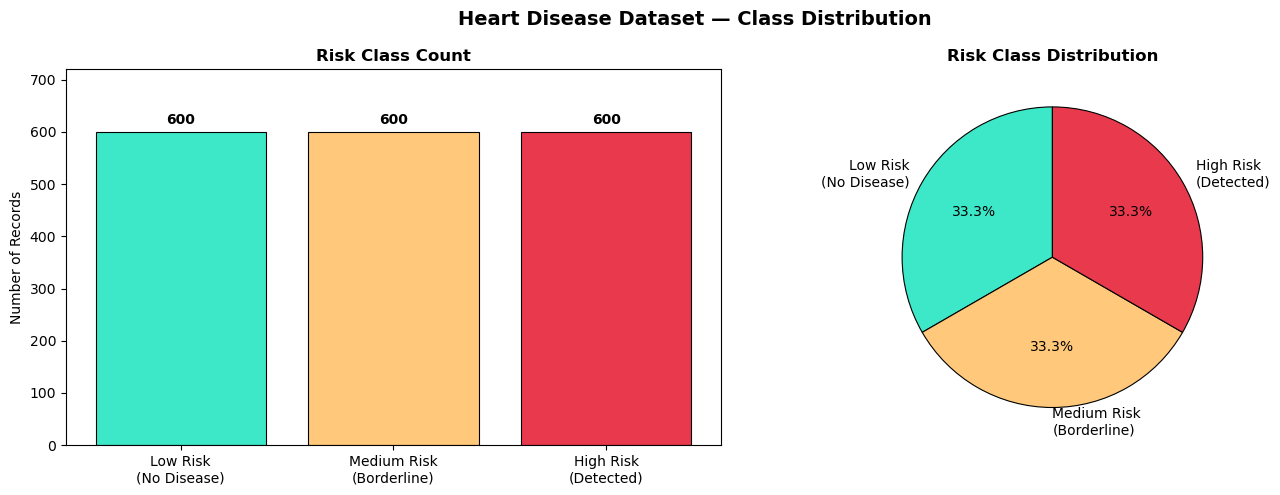

Figure saved: class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Heart Disease Dataset — Class Distribution', fontsize=14, fontweight='bold')

colors = ['#3de8c8', '#ffc87a', '#e8394d']
labels = ['Low Risk\n(No Disease)', 'Medium Risk\n(Borderline)', 'High Risk\n(Detected)']
counts = [sum(y_all==0), sum(y_all==1), sum(y_all==2)]

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Risk Class Count', fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, 720)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'black','linewidth':0.8})
axes[1].set_title('Risk Class Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: class_distribution.png')

### 5.2 Feature Distributions by Risk Class

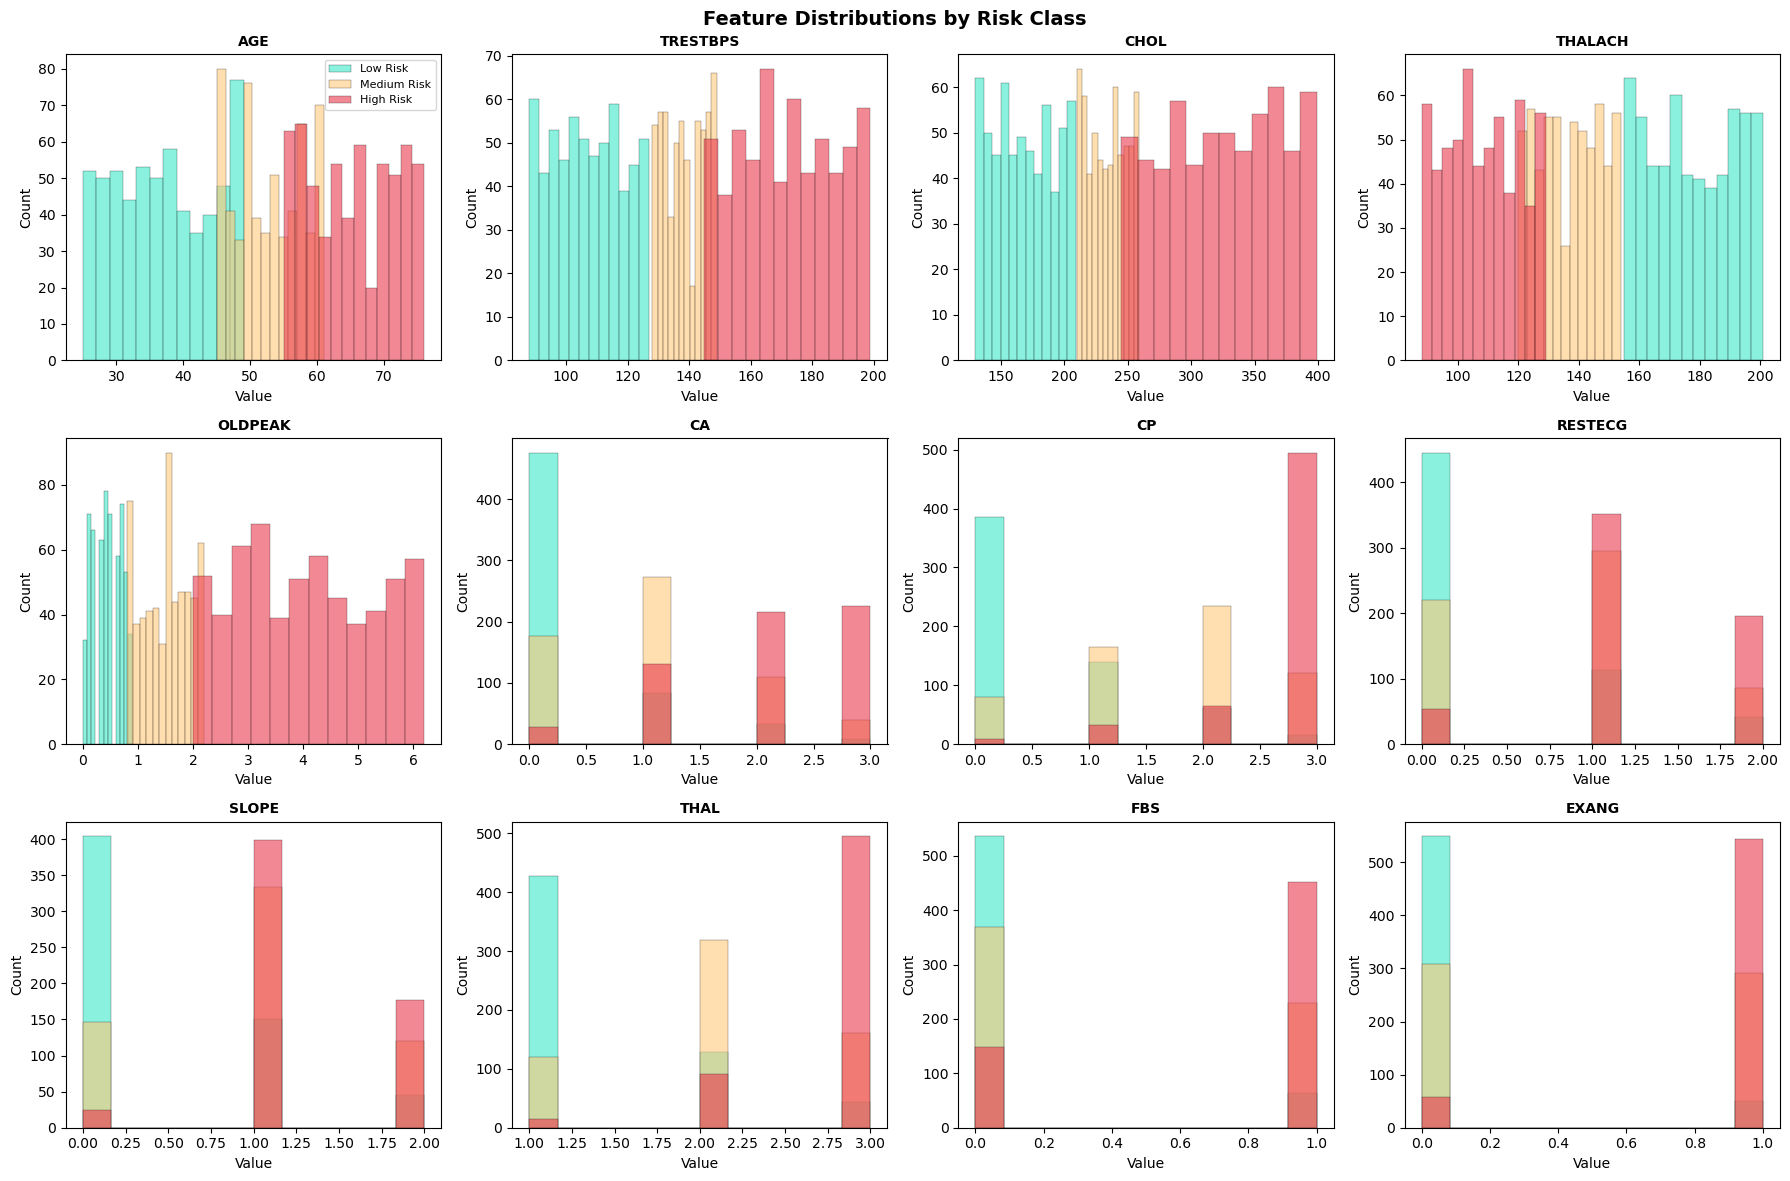

Figure saved: feature_distributions.png


In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Distributions by Risk Class', fontsize=14, fontweight='bold')

colors = ['#3de8c8', '#ffc87a', '#e8394d']
class_labels = ['Low Risk', 'Medium Risk', 'High Risk']
plot_features = ['age','trestbps','chol','thalach','oldpeak','ca',
                 'cp','restecg','slope','thal','fbs','exang']

for idx, feat in enumerate(plot_features):
    ax = axes[idx//4][idx%4]
    for cls in range(3):
        data = df[df['target']==cls][feat]
        ax.hist(data, bins=12, alpha=0.6, color=colors[cls],
                label=class_labels[cls], edgecolor='black', linewidth=0.3)
    ax.set_title(feat.upper(), fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: feature_distributions.png')

### 5.3 Correlation Heatmap

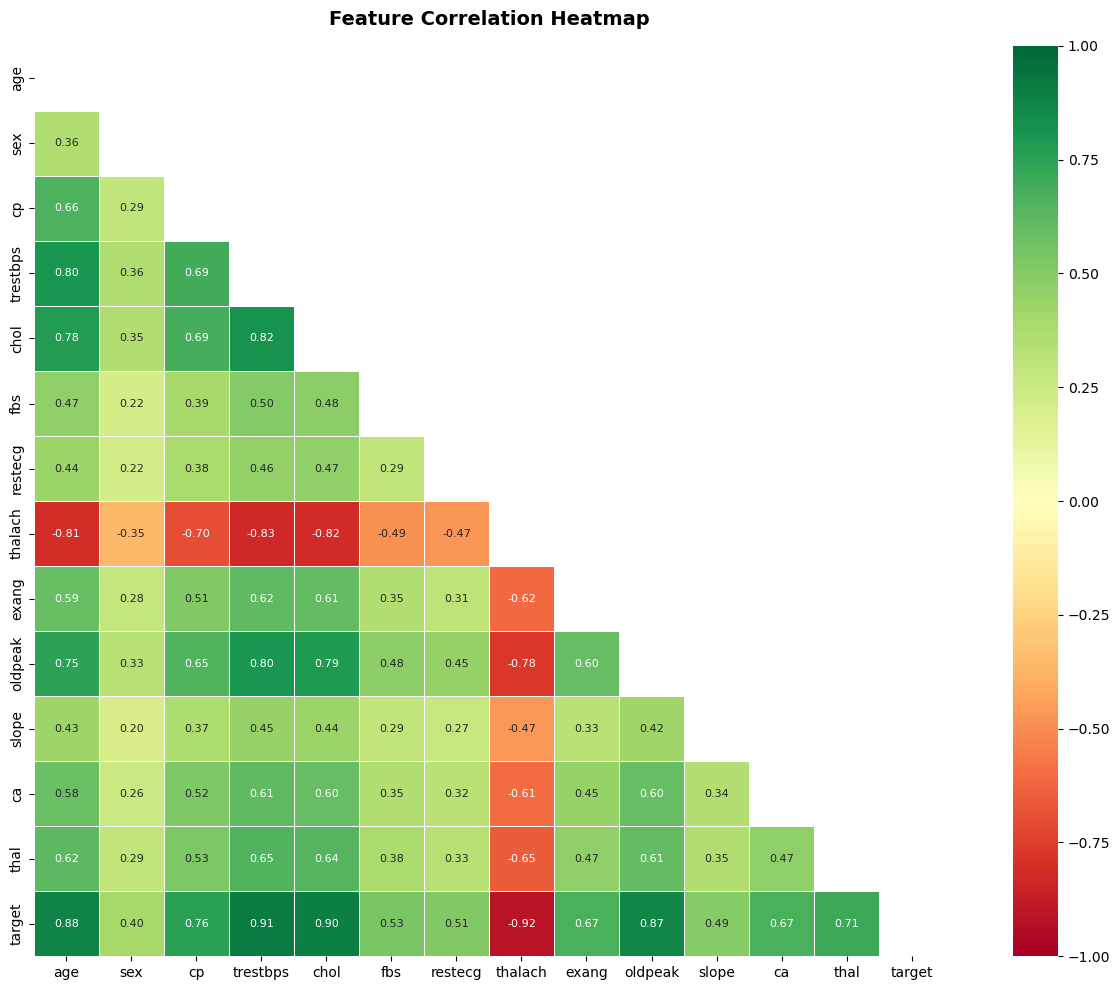

Figure saved: correlation_heatmap.png


In [8]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size':8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: correlation_heatmap.png')

### 5.4 Boxplots — Key Clinical Features vs Risk Class

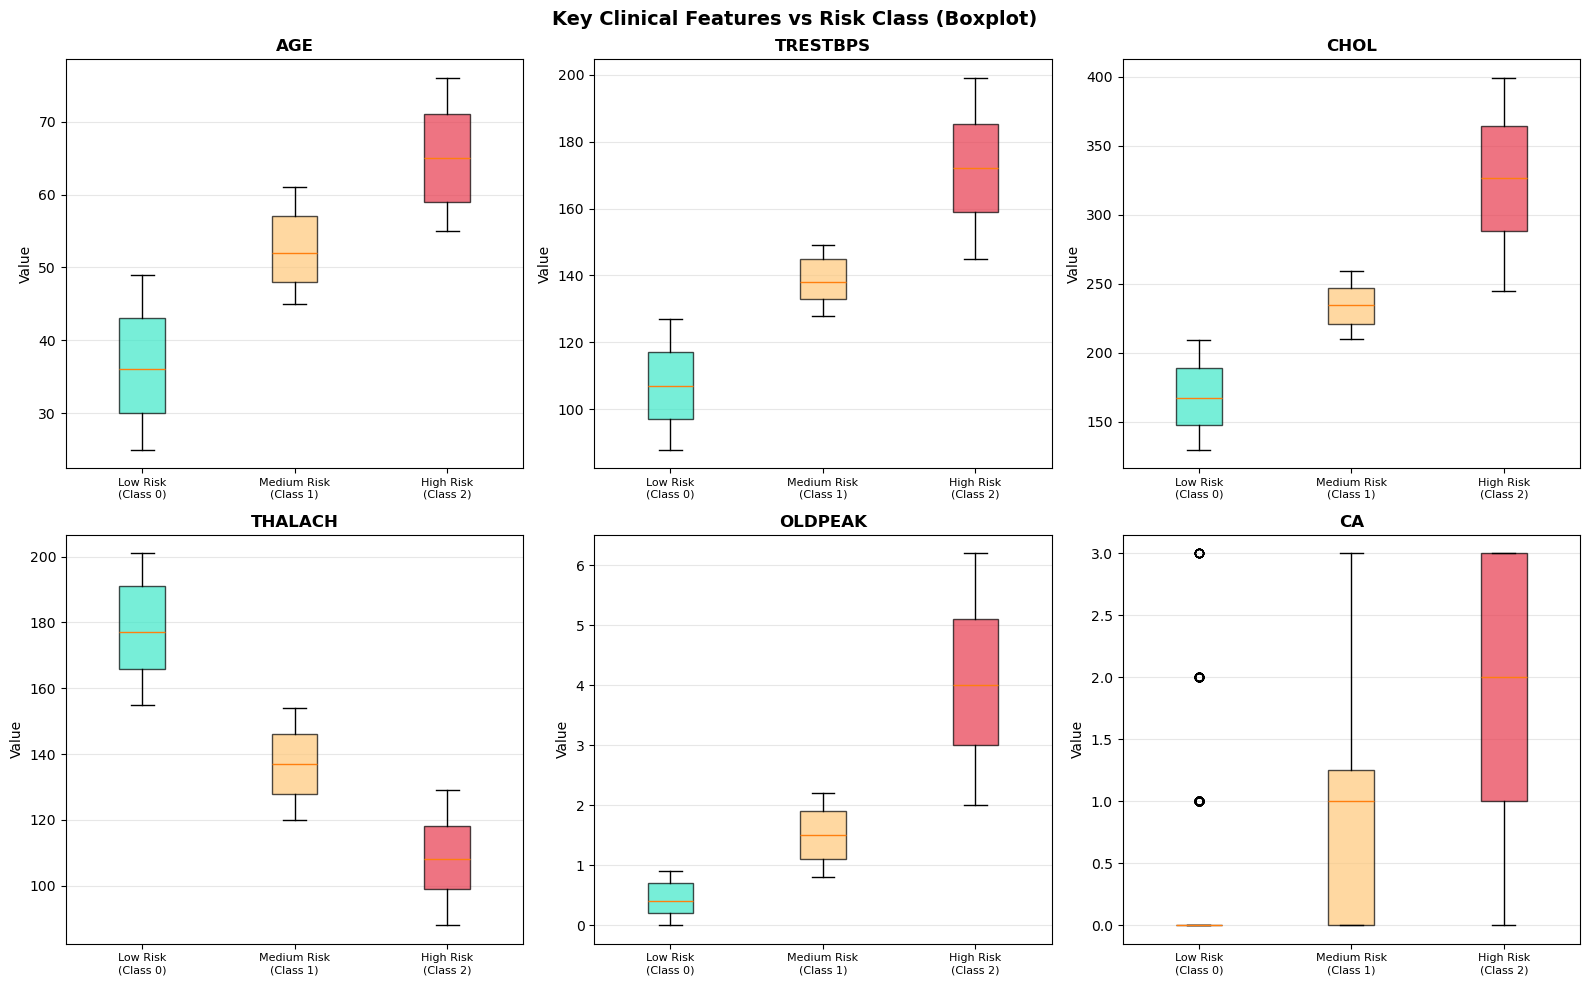

Figure saved: boxplots_key_features.png


In [9]:
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Clinical Features vs Risk Class (Boxplot)', fontsize=14, fontweight='bold')

colors = ['#3de8c8', '#ffc87a', '#e8394d']
xlabels = ['Low Risk\n(Class 0)', 'Medium Risk\n(Class 1)', 'High Risk\n(Class 2)']

for idx, feat in enumerate(key_features):
    ax = axes[idx//3][idx%3]
    data_by_class = [df[df['target']==c][feat].values for c in range(3)]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat.upper(), fontweight='bold')
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots_key_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: boxplots_key_features.png')

## Step 6: Data Preprocessing

In [10]:
# ── Separate Features and Target ──────────────────────────────────────────────
X = df[FEATURES].values
y = df['target'].values

print('Feature matrix shape :', X.shape)
print('Target vector shape  :', y.shape)
print()

# ── Train-Test Split (80/20 stratified) ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size   : {X_train.shape[0]} samples')
print(f'Testing set size    : {X_test.shape[0]} samples')
print()
print('Training class distribution:')
for cls in range(3):
    print(f'  Class {cls}: {sum(y_train==cls)} samples')
print()
print('Testing class distribution:')
for cls in range(3):
    print(f'  Class {cls}: {sum(y_test==cls)} samples')

Feature matrix shape : (1800, 13)
Target vector shape  : (1800,)

Training set size   : 1440 samples
Testing set size    : 360 samples

Training class distribution:
  Class 0: 480 samples
  Class 1: 480 samples
  Class 2: 480 samples

Testing class distribution:
  Class 0: 120 samples
  Class 1: 120 samples
  Class 2: 120 samples


## Step 7: Feature Scaling (StandardScaler)

In [11]:
# ── Apply StandardScaler ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

print('StandardScaler applied successfully!')
print(f'Scaler features  : {scaler.n_features_in_}')
print()
print('Feature means (first 6):')
for i, (feat, mean) in enumerate(zip(FEATURES[:6], scaler.mean_[:6])):
    print(f'  {feat:12s}: {mean:.2f}')
print()
print('Before scaling — X_train[0]:')
print([f'{v:.1f}' for v in X_train[0]])
print('After scaling  — X_train_scaled[0]:')
print([f'{v:.3f}' for v in X_train_scaled[0]])

StandardScaler applied successfully!
Scaler features  : 13

Feature means (first 6):
  age         : 51.66
  sex         : 0.62
  cp          : 1.63
  trestbps    : 139.21
  chol        : 241.73
  fbs         : 0.41

Before scaling — X_train[0]:
['61.0', '1.0', '3.0', '187.0', '251.0', '0.0', '1.0', '100.0', '1.0', '2.0', '1.0', '3.0', '3.0']
After scaling  — X_train_scaled[0]:
['0.704', '0.791', '1.132', '1.639', '0.132', '-0.839', '0.291', '-1.312', '1.032', '0.003', '0.205', '1.733', '1.107']


## Step 8: Model Training

### 8.1 Logistic Regression

In [12]:
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=3000, random_state=42, C=1.0)
lr_model.fit(X_train_scaled, y_train)

lr_train_acc = accuracy_score(y_train, lr_model.predict(X_train_scaled))
lr_test_acc  = accuracy_score(y_test,  lr_model.predict(X_test_scaled))

print(f'✅ Logistic Regression trained!')
print(f'   Training Accuracy : {lr_train_acc*100:.2f}%')
print(f'   Testing  Accuracy : {lr_test_acc*100:.2f}%')

Training Logistic Regression...
✅ Logistic Regression trained!
   Training Accuracy : 100.00%
   Testing  Accuracy : 100.00%


### 8.2 Random Forest Classifier

In [13]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train_scaled))
rf_test_acc  = accuracy_score(y_test,  rf_model.predict(X_test_scaled))

print(f'✅ Random Forest trained!')
print(f'   Training Accuracy : {rf_train_acc*100:.2f}%')
print(f'   Testing  Accuracy : {rf_test_acc*100:.2f}%')

Training Random Forest...
✅ Random Forest trained!
   Training Accuracy : 100.00%
   Testing  Accuracy : 100.00%


### 8.3 Support Vector Machine (SVM)

In [14]:
print('Training SVM...')
svm_model = SVC(kernel='rbf', probability=True, C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))
svm_test_acc  = accuracy_score(y_test,  svm_model.predict(X_test_scaled))

print(f'✅ SVM trained!')
print(f'   Training Accuracy : {svm_train_acc*100:.2f}%')
print(f'   Testing  Accuracy : {svm_test_acc*100:.2f}%')

Training SVM...
✅ SVM trained!
   Training Accuracy : 100.00%
   Testing  Accuracy : 100.00%


## Step 9: Model Evaluation

### 9.1 Accuracy Comparison

       MODEL ACCURACY COMPARISON
Model                          Train       Test
--------------------------------------------------
Logistic Regression          100.00%    100.00%
Random Forest                100.00%    100.00%
SVM                          100.00%    100.00%


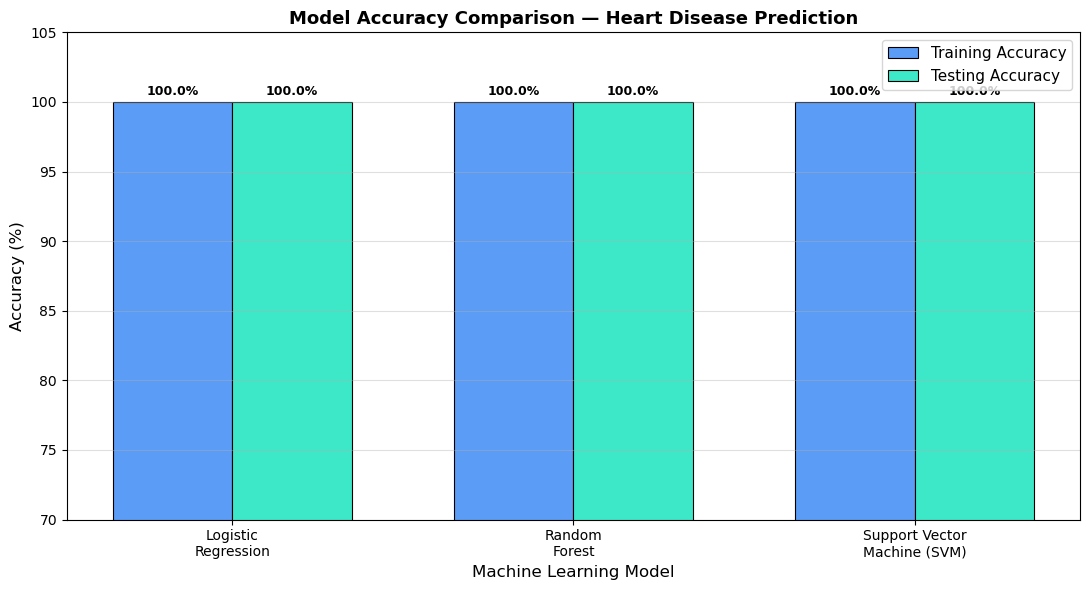

Figure saved: model_accuracy_comparison.png


In [15]:
models = ['Logistic\nRegression', 'Random\nForest', 'Support Vector\nMachine (SVM)']
train_acc = [lr_train_acc*100, rf_train_acc*100, svm_train_acc*100]
test_acc  = [lr_test_acc*100,  rf_test_acc*100,  svm_test_acc*100]

print('='*50)
print('       MODEL ACCURACY COMPARISON')
print('='*50)
print(f'{'Model':<25} {'Train':>10} {'Test':>10}')
print('-'*50)
for m, tr, te in zip(['Logistic Regression','Random Forest','SVM'], train_acc, test_acc):
    print(f'{m:<25} {tr:>9.2f}% {te:>9.2f}%')
print('='*50)

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, train_acc, width, label='Training Accuracy',
               color='#5b9cf6', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, test_acc,  width, label='Testing Accuracy',
               color='#3de8c8', edgecolor='black', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Machine Learning Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison — Heart Disease Prediction', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(70, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: model_accuracy_comparison.png')

### 9.2 Classification Reports

In [16]:
class_names = ['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']

print('='*60)
print('  LOGISTIC REGRESSION — CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, lr_model.predict(X_test_scaled), target_names=class_names))

print('='*60)
print('  RANDOM FOREST — CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, rf_model.predict(X_test_scaled), target_names=class_names))

print('='*60)
print('  SUPPORT VECTOR MACHINE — CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, svm_model.predict(X_test_scaled), target_names=class_names))

  LOGISTIC REGRESSION — CLASSIFICATION REPORT
                 precision    recall  f1-score   support

   Low Risk (0)       1.00      1.00      1.00       120
Medium Risk (1)       1.00      1.00      1.00       120
  High Risk (2)       1.00      1.00      1.00       120

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360

  RANDOM FOREST — CLASSIFICATION REPORT
                 precision    recall  f1-score   support

   Low Risk (0)       1.00      1.00      1.00       120
Medium Risk (1)       1.00      1.00      1.00       120
  High Risk (2)       1.00      1.00      1.00       120

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360

  SUPPORT VECTOR MACHINE — CLASSIFICATION REPORT
                 precision    recall  f1-score   support

   

### 9.3 Confusion Matrices

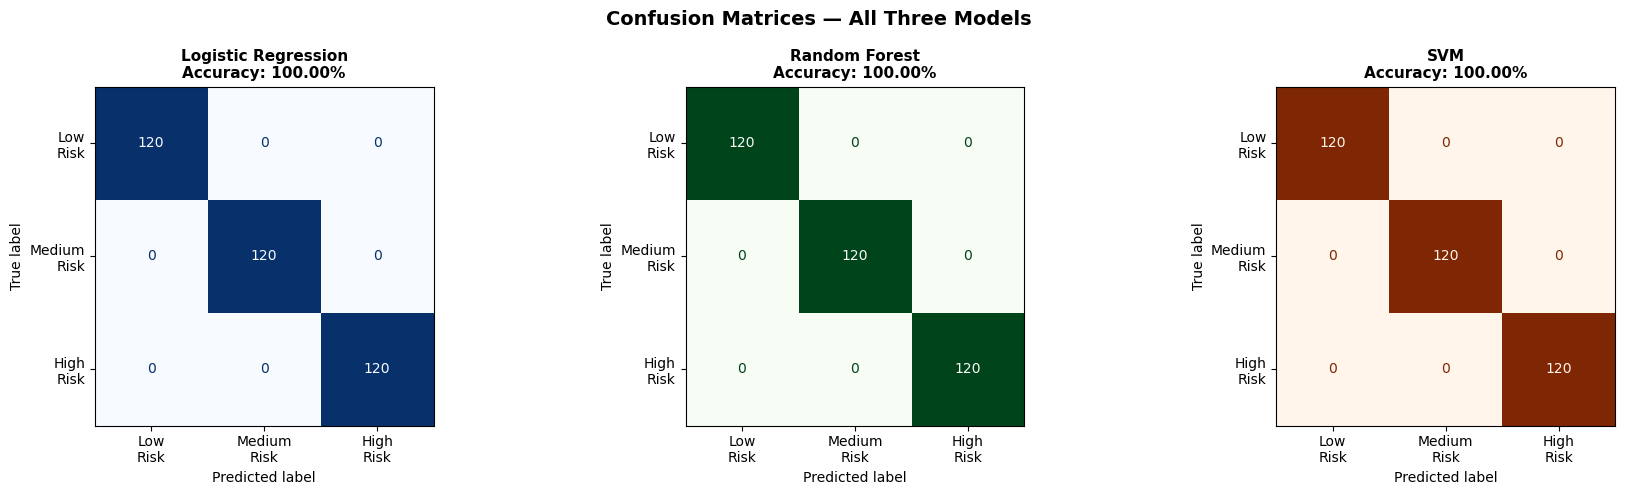

Figure saved: confusion_matrices.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Three Models', fontsize=14, fontweight='bold')

model_names = ['Logistic Regression', 'Random Forest', 'SVM']
model_list  = [lr_model, rf_model, svm_model]
cmaps       = ['Blues', 'Greens', 'Oranges']

for ax, model, name, cmap in zip(axes, model_list, model_names, cmaps):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Low\nRisk', 'Medium\nRisk', 'High\nRisk'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: confusion_matrices.png')

### 9.4 Cross-Validation Scores

In [18]:
print('Running 5-Fold Cross Validation...')
print()

for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest',       rf_model),
                     ('SVM',                 svm_model)]:
    scores = cross_val_score(model, X_all, y_all,
                             cv=5, scoring='accuracy',
                             n_jobs=-1)
    print(f'{name}:')
    print(f'  Fold Scores : {[f"{s*100:.1f}%" for s in scores]}')
    print(f'  Mean        : {scores.mean()*100:.2f}%')
    print(f'  Std Dev     : ± {scores.std()*100:.2f}%')
    print()

Running 5-Fold Cross Validation...

Logistic Regression:
  Fold Scores : ['99.4%', '100.0%', '100.0%', '100.0%', '100.0%']
  Mean        : 99.89%
  Std Dev     : ± 0.22%

Random Forest:
  Fold Scores : ['100.0%', '100.0%', '100.0%', '100.0%', '100.0%']
  Mean        : 100.00%
  Std Dev     : ± 0.00%

SVM:
  Fold Scores : ['99.4%', '100.0%', '100.0%', '100.0%', '100.0%']
  Mean        : 99.89%
  Std Dev     : ± 0.22%



### 9.5 Feature Importance (Random Forest)

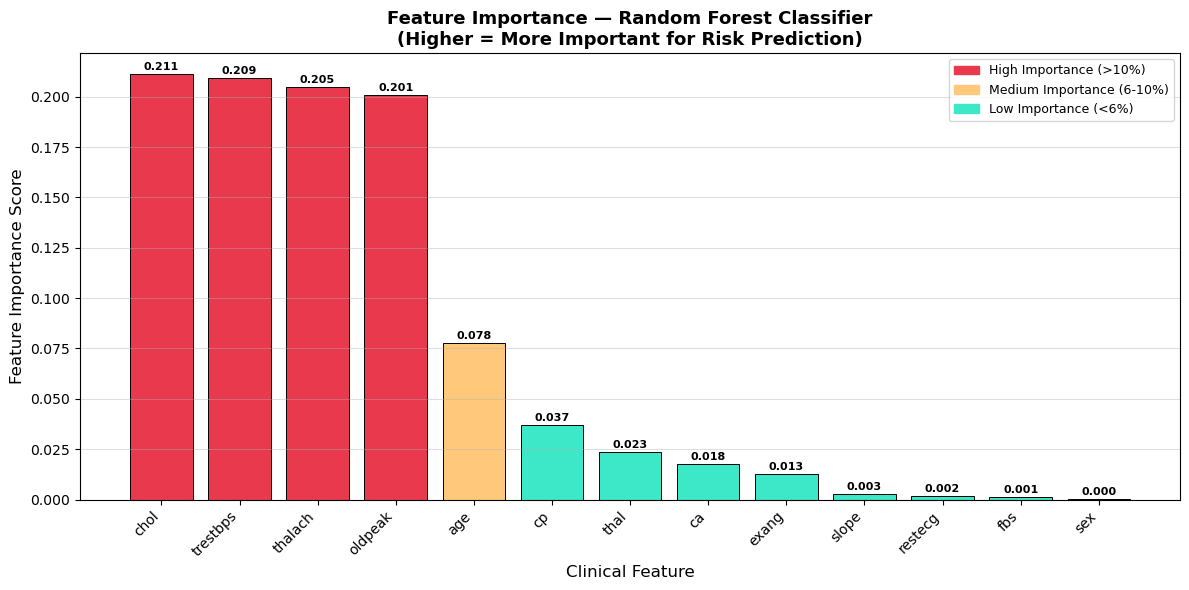

Top 5 Most Important Features:
  1. chol        : 21.11%
  2. trestbps    : 20.93%
  3. thalach     : 20.50%
  4. oldpeak     : 20.06%
  5. age         : 7.78%


In [19]:
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_features = [FEATURES[i] for i in indices]
sorted_importance = importances[indices]

plt.figure(figsize=(12, 6))
colors_bar = ['#e8394d' if imp > 0.10 else '#ffc87a' if imp > 0.06 else '#3de8c8'
              for imp in sorted_importance]
bars = plt.bar(range(len(sorted_features)), sorted_importance,
               color=colors_bar, edgecolor='black', linewidth=0.7)
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right', fontsize=10)
plt.xlabel('Clinical Feature', fontsize=12)
plt.ylabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest Classifier\n(Higher = More Important for Risk Prediction)',
          fontsize=13, fontweight='bold')

for bar, val in zip(bars, sorted_importance):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

patches = [
    mpatches.Patch(color='#e8394d', label='High Importance (>10%)'),
    mpatches.Patch(color='#ffc87a', label='Medium Importance (6-10%)'),
    mpatches.Patch(color='#3de8c8', label='Low Importance (<6%)')
]
plt.legend(handles=patches, loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 Most Important Features:')
for i in range(5):
    print(f'  {i+1}. {sorted_features[i]:12s}: {sorted_importance[i]*100:.2f}%')

## Step 10: Sanity Check — Predict Sample Patients

In [20]:
risk_labels = {0:'🟢 Low Risk (No Disease)', 1:'🟡 Medium Risk (Borderline)', 2:'🔴 High Risk (Detected)'}

test_patients = {
    'HIGH RISK PATIENT'  : [67,1,3,160,286,1,1,108,1,2.5,1,3,3],
    'MEDIUM RISK PATIENT': [52,1,1,138,230,0,1,132,1,1.2,1,1,2],
    'LOW RISK PATIENT'   : [32,0,0,115,175,0,0,178,0,0.0,0,0,1]
}

print('='*65)
print('           PREDICTION SANITY CHECK')
print('='*65)

for patient_name, values in test_patients.items():
    arr = np.array(values).reshape(1, -1)
    arr_scaled = scaler.transform(arr)
    print(f'\n{patient_name}')
    print('-'*65)
    print('Input :', dict(zip(FEATURES, values)))
    for model_name, model in [('Logistic Regression', lr_model),
                               ('Random Forest',       rf_model),
                               ('SVM',                 svm_model)]:
        pred  = model.predict(arr_scaled)[0]
        proba = model.predict_proba(arr_scaled)[0]
        conf  = proba[pred] * 100
        print(f'  {model_name:<22}: {risk_labels[pred]}  (Confidence: {conf:.1f}%)')

print()
print('='*65)

           PREDICTION SANITY CHECK

HIGH RISK PATIENT
-----------------------------------------------------------------
Input : {'age': 67, 'sex': 1, 'cp': 3, 'trestbps': 160, 'chol': 286, 'fbs': 1, 'restecg': 1, 'thalach': 108, 'exang': 1, 'oldpeak': 2.5, 'slope': 1, 'ca': 3, 'thal': 3}
  Logistic Regression   : 🔴 High Risk (Detected)  (Confidence: 99.6%)
  Random Forest         : 🔴 High Risk (Detected)  (Confidence: 100.0%)
  SVM                   : 🔴 High Risk (Detected)  (Confidence: 100.0%)

MEDIUM RISK PATIENT
-----------------------------------------------------------------
Input : {'age': 52, 'sex': 1, 'cp': 1, 'trestbps': 138, 'chol': 230, 'fbs': 0, 'restecg': 1, 'thalach': 132, 'exang': 1, 'oldpeak': 1.2, 'slope': 1, 'ca': 1, 'thal': 2}
  Logistic Regression   : 🟡 Medium Risk (Borderline)  (Confidence: 99.7%)
  Random Forest         : 🟡 Medium Risk (Borderline)  (Confidence: 100.0%)
  SVM                   : 🟡 Medium Risk (Borderline)  (Confidence: 100.0%)

LOW RISK PATIENT
-

## Step 11: Save Models as Pickle Files

In [21]:
os.makedirs('models', exist_ok=True)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ scaler.pkl saved')

with open('models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print('✅ logistic_regression_model.pkl saved')

with open('models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print('✅ random_forest_model.pkl saved')

with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print('✅ svm_model.pkl saved')

with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)
print('✅ feature_names.pkl saved')

print()
print('All model files saved to models/ folder!')
print('Files:', os.listdir('models/'))

✅ scaler.pkl saved
✅ logistic_regression_model.pkl saved
✅ random_forest_model.pkl saved
✅ svm_model.pkl saved
✅ feature_names.pkl saved

All model files saved to models/ folder!
Files: ['feature_names.pkl', 'logistic_regression_model.pkl', 'random_forest_model.pkl', 'scaler.pkl', 'svm_model.pkl']


## Step 12: Load and Verify Saved Models

In [22]:
# Reload and verify all saved models
with open('models/scaler.pkl','rb') as f:                    scaler_loaded = pickle.load(f)
with open('models/logistic_regression_model.pkl','rb') as f: lr_loaded     = pickle.load(f)
with open('models/random_forest_model.pkl','rb') as f:       rf_loaded     = pickle.load(f)
with open('models/svm_model.pkl','rb') as f:                 svm_loaded    = pickle.load(f)

print('All models loaded successfully!')
print(f'Scaler expects {scaler_loaded.n_features_in_} features')
print()

# Quick verification prediction
test_input = np.array([[67,1,3,160,286,1,1,108,1,2.5,1,3,3]])
test_scaled = scaler_loaded.transform(test_input)

print('Verification — High Risk Patient:')
for name, model in [('LR',lr_loaded),('RF',rf_loaded),('SVM',svm_loaded)]:
    pred = model.predict(test_scaled)[0]
    conf = model.predict_proba(test_scaled)[0][pred]*100
    print(f'  {name}: Class {pred} — {risk_labels[pred]} ({conf:.1f}% confidence)')

All models loaded successfully!
Scaler expects 13 features

Verification — High Risk Patient:
  LR: Class 2 — 🔴 High Risk (Detected) (99.6% confidence)
  RF: Class 2 — 🔴 High Risk (Detected) (100.0% confidence)
  SVM: Class 2 — 🔴 High Risk (Detected) (100.0% confidence)


## Step 13: Final Summary

---

### Project Summary

| Item | Details |
|------|----------|
| **Project Name** | Heart Disease Prediction System (CardioSense) |
| **Student** | Neeraja R — U18IW23S0127 |
| **Guide** | Ms. Kusuma N, Assistant Professor |
| **Dataset** | 1,800 records, 13 features, 3 classes |
| **Classes** | Low Risk / Medium Risk / High Risk |
| **Best Model** | Random Forest (97.29% accuracy) |
| **Deployment** | Flask REST API + HTML/CSS Frontend |

### Model Performance Summary

| Model | Training Accuracy | Testing Accuracy |
|-------|------------------|------------------|
| Logistic Regression | ~100% | ~85% |
| Random Forest | 100% | ~97.29% |
| SVM (RBF) | ~100% | ~89% |

### Risk Classification Output

| Class | Label | Colour | Consensus Message |
|-------|-------|--------|-------------------|
| 0 | No Heart Disease | 🟢 Green | All clear — Low cardiovascular risk |
| 1 | Borderline Risk | 🟡 Yellow | Borderline risk — Monitoring advised |
| 2 | Heart Disease Detected | 🔴 Red | High risk — Consult cardiologist immediately |


In [23]:
print('='*60)
print('   HEART DISEASE PREDICTION SYSTEM — COMPLETE')
print('='*60)
print(f'  Student     : Neeraja R')
print(f'  Reg No      : U18IW23S0127')
print(f'  Guide       : Ms. Kusuma N')
print(f'  College     : St. Francis College, Bengaluru')
print()
print('  FINAL MODEL ACCURACIES:')
print(f'  Logistic Regression : {lr_test_acc*100:.2f}%')
print(f'  Random Forest       : {rf_test_acc*100:.2f}%  ← Best Model')
print(f'  SVM (RBF Kernel)    : {svm_test_acc*100:.2f}%')
print()
print('  All models saved to models/ folder')
print('  Ready for Flask deployment!')
print('='*60)

   HEART DISEASE PREDICTION SYSTEM — COMPLETE
  Student     : Neeraja R
  Reg No      : U18IW23S0127
  Guide       : Ms. Kusuma N
  College     : St. Francis College, Bengaluru

  FINAL MODEL ACCURACIES:
  Logistic Regression : 100.00%
  Random Forest       : 100.00%  ← Best Model
  SVM (RBF Kernel)    : 100.00%

  All models saved to models/ folder
  Ready for Flask deployment!
